In [1]:

import os
import shutil

if os.path.exists("/content/kpk_project"):
    shutil.rmtree("/content/kpk_project")

!git clone https://github.com/Sabrina2701/kpk_project.git /content/kpk_project
%cd /content/kpk_project

#Installing dependencies
!pip install python-chess torch --quiet

Cloning into '/content/kpk_project'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 22 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 40.04 KiB | 661.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/kpk_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 47.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# 1. Controlla il remote (deve mostrare l'URL del tuo repository)
!git remote -v

origin	https://github.com/Sabrina2701/kpk_project.git (fetch)
origin	https://github.com/Sabrina2701/kpk_project.git (push)


**Validation Pipeline**

In [3]:
import os
import urllib.request
import chess
import chess.syzygy

print("==================================================")
print("DOWNLOAD TABLES SYZYGY (3 PIECES)")
print("==================================================")
syzygy_dir = "/content/kpk_project/syzygy"
os.makedirs(syzygy_dir, exist_ok=True)

syzygy_files = [
    "KPvK.rtbw", "KPvK.rtbz",
    "KQvK.rtbw", "KQvK.rtbz",
    "KRvK.rtbw", "KRvK.rtbz",
    "KBvK.rtbw", "KBvK.rtbz",
    "KNvK.rtbw", "KNvK.rtbz",
]

base_url = "https://tablebase.lichess.ovh/tables/standard/3-4-5-"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

for fname in syzygy_files:
    dest_path = os.path.join(syzygy_dir, fname)
    if not os.path.exists(dest_path) or os.path.getsize(dest_path) == 0:
        ext = fname.split('.')[-1]
        subfolder = "wdl" if ext == "rtbw" else "dtz"
        url = f"{base_url}{subfolder}/{fname}"
        req = urllib.request.Request(url, headers=headers)
        try:
            with urllib.request.urlopen(req) as response, open(dest_path, 'wb') as out_file:
                out_file.write(response.read())
            print(f"Downloaded: {fname} ({os.path.getsize(dest_path)} bytes)")
        except Exception as e:
            print(f"Error Downloading {fname}: {e}")
    else:
        print(f"Already present: {fname}")

print("\n==================================================")
print("VERIFYING CHESS TABLEBASE")
print("==================================================")
tb = chess.syzygy.open_tablebase(syzygy_dir)
test_board = chess.Board("8/4P3/8/8/4k3/8/8/4K3 w - - 0 1")
wdl_val = tb.probe_wdl(test_board)
print(f"Probe WDL Promotion: {wdl_val} (Expected 2 = Victory)")

print("\n==================================================")
print("START VALIDATION")
print("==================================================")
!python validate.py --tablebase_dir ./syzygy --n_games 200

DOWNLOAD TABLES SYZYGY (3 PIECES)
Downloaded: KPvK.rtbw (7824 bytes)
Downloaded: KPvK.rtbz (4176 bytes)
Downloaded: KQvK.rtbw (272 bytes)
Downloaded: KQvK.rtbz (5392 bytes)
Downloaded: KRvK.rtbw (208 bytes)
Downloaded: KRvK.rtbz (7632 bytes)
Downloaded: KBvK.rtbw (80 bytes)
Downloaded: KBvK.rtbz (80 bytes)
Downloaded: KNvK.rtbw (80 bytes)
Downloaded: KNvK.rtbz (80 bytes)

VERIFYING CHESS TABLEBASE
Probe WDL Promotion: 2 (Expected 2 = Victory)

START VALIDATION
Generating 200 KPK games for validation...

OK   vocab_coverage: all legal moves across 1000 sampled positions are tokenizable
OK   played_moves_in_vocab: all 10709 moves played across 200 games are tokenizable
OK   game_legality: all 200 games are legal end-to-end
OK   dtz_consistency: 0/7976 label mismatches on replay (0.0000%)
OK   terminal_outcomes: 0 mismatches between mate/stalemate and recorded WDL
OK   no_stuck_cycles: 0/76 decisive games ended in a non-progressing move cycle (0.00%, threshold 1%)
INFO critical_sampler_ef

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Generation
I generated a 200k-game KPK self-play dataset (in 50k-game increments) using python-chess, integrated with a 3-piece Syzygy tablebase. This guarantees exact and noise-free Win/Draw/Loss (WDL) and Distance-to-Zeroing (DTZ) ground truth for all training, probing and evaluation targets. Positions were generated using a critical-position sampler (at 0.75, defending king within 1 square of the pawn), paired with a quasi-optimal move policy to maximize tactical depth.







---
This simple test in the next cell is what gives value to the results in section 3,4 and 5, because a purely random dataset would have weakened the interesting signal I were trying to measure.

The specific values of `p_critical_start` and `critical_king_radius` were chosen through a test to verify that I needed to consider only the configurations where the defending king was forced to be within a small radius from the pawn.
I did a zugzwang test: take a position, flip whose move it is, while keeping the pieces fixed, and check whether the winner flips. Zugzwang in fact means that the outcome depends on who has the move, not just on the position.

--> radius=3 and radius=2 had similar true-zugzwang rates, 28% each (on a sample of 150 positions): no effect from loosening the radius that far.

--> radius=1 (king forced adjacent to the pawn) nearly doubled it, to 48–57% depending on the run.

I chose radius=1 and raised p_critical_start to 0.75 as the final defaults, verified again on real generated data at scale: 19.3% zugzwang rate for the generic half against 56.7% for the critical half, confirmed reproducible across two independent random seeds later in the project.

In [ ]:
from selfplay import SelfPlayConfig, random_kpk_position
from tablebase import Tablebase
import random, chess

tb = Tablebase("./syzygy")
rng = random.Random(0)

def zugzwang_rate(radius, n=150):
    cfg = SelfPlayConfig(critical_king_radius=radius)
    count = valid = 0
    while valid < n:
        board = random_kpk_position(rng, critical=True, cfg=cfg)
        w1 = tb.wdl(board); white1 = w1 if board.turn == chess.WHITE else -w1
        board.turn = not board.turn
        if not board.is_valid():
            continue
        w2 = tb.wdl(board); white2 = w2 if board.turn == chess.WHITE else -w2
        if (white1 > 0) != (white2 > 0):
            count += 1
        valid += 1
    return count / n

for r in [3, 2, 1]:
    print(f"critical_king_radius={r} -> zugzwang_rate={zugzwang_rate(r):.1%}")

critical_king_radius=3 -> zugzwang_rate=28.7%
critical_king_radius=2 -> zugzwang_rate=28.0%
critical_king_radius=1 -> zugzwang_rate=48.7%


In [ ]:
# data generation 1
!python data_gen.py --domain kpk --n_games 50000 --out /content/drive/MyDrive/kpk_project/data --tablebase_dir ./syzygy

Resuming: 30/10 shards already on disk, skipping them.
Done. 150000 games across 10 shards in /content/drive/MyDrive/kpk_project/data/


In [ ]:
# data generation 2 (continua dagli shard già fatti, ne genera altri 10 per arrivare a 100k)
!python data_gen.py --domain kpk --n_games 100000 --out /content/drive/MyDrive/kpk_project/data --tablebase_dir ./syzygy

Resuming: 30/20 shards already on disk, skipping them.
Done. 150000 games across 20 shards in /content/drive/MyDrive/kpk_project/data/


In [ ]:
# data generation 3
!python data_gen.py --domain kpk --n_games 150000 --out /content/drive/MyDrive/kpk_project/data --tablebase_dir ./syzygy

Resuming: 30/30 shards already on disk, skipping them.
Done. 150000 games across 30 shards in /content/drive/MyDrive/kpk_project/data/


In [ ]:
# data generation 4
!python data_gen.py --domain kpk --n_games 200000 --out /content/drive/MyDrive/kpk_project/data --tablebase_dir ./syzygy

Resuming: 30/40 shards already on disk, skipping them.
[shard 31/40] 5000 games in 485.4s (10.3 games/s) | ETA for remaining shards: 72.8 min
[shard 32/40] 5000 games in 416.0s (12.0 games/s) | ETA for remaining shards: 55.5 min
[shard 33/40] 5000 games in 410.0s (12.2 games/s) | ETA for remaining shards: 47.8 min
[shard 34/40] 5000 games in 405.4s (12.3 games/s) | ETA for remaining shards: 40.5 min
[shard 35/40] 5000 games in 409.7s (12.2 games/s) | ETA for remaining shards: 34.1 min
[shard 36/40] 5000 games in 414.6s (12.1 games/s) | ETA for remaining shards: 27.6 min
[shard 37/40] 5000 games in 406.9s (12.3 games/s) | ETA for remaining shards: 20.3 min
[shard 38/40] 5000 games in 408.1s (12.3 games/s) | ETA for remaining shards: 13.6 min
[shard 39/40] 5000 games in 403.2s (12.4 games/s) | ETA for remaining shards: 6.7 min
[shard 40/40] 5000 games in 412.5s (12.1 games/s) | ETA for remaining shards: 0.0 min
Done. 200000 games across 40 shards in /content/drive/MyDrive/kpk_project/dat

#M1
The goal is to train a Transformer to predict the next move when it has only the sequence of moves played so far: this means no board state and no piece list. This phase is the substrate for everything that comes after: the interpretability work built on top of it needs to be standing on solid ground.  Instead of PyTorch's built-in nn.TransformerEncoder, I produced the attention blocks (causal self-attention via scaled_dot_product_attention, a pre-LayerNorm residual structure), also in anticipation of M5 where causal patching requires overwriting the residual stream at a specific mid-forward-pass. Here I also have a manually constructed a boolean mask combining causality and padding into one tensor (`causal & key_padding`), passed with `is_causal=False`.
Every epoch's model, optimizer and scheduler state get checkpointed to a `last.pt`, which is always overwritten; a `best.pt` is saved only when validation loss improves. For this model size (5.7M parameters) on a domain this constrained, others work with similar Transformers suggested convergence somewhere in the 7,000–15,000 gradient-step range, which maps to roughly 20–40 epochs at 371 steps/epoch. I picked 25 as a middle point, favoring slight overshoot since best.pt always captures the peak regardless of how long training runs afterward. Validation accuracy had already plateaued by epoch 14 (80.6%) and only inched up to 81.2% by epoch 25, meaning the chosen epoch count was neither too small or too large.


In [ ]:
#Sanity check of the training loop on a single shard before committing to the full run.

DATA_DIR = "/content/drive/MyDrive/kpk_project/data"
CKPT_DIR = "/content/drive/MyDrive/kpk_project/checkpoints"

!mkdir -p data_smoke
!cp "{DATA_DIR}/shard_00000.jsonl" "{DATA_DIR}/manifest.json" data_smoke/
!python train_m1.py --data_dir ./data_smoke --out_dir "{CKPT_DIR}_smoke" --epochs 2 --batch_size 64

Mounted at /content/drive
device: cuda
Loading dataset (replays every game once to build M2/M3 labels -- can take a bit on a large dataset, this only happens once per run)...
  5000 games loaded in 0.1s
  train=4750  val=250
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1)  (5.71M params)
  [throughput check] ~0.34s/batch -> ~0.4 min for this epoch's training pass
epoch 1/2 | train_loss=4.9335 | val_loss=3.8075 val_ppl=45.04 val_top1_acc=0.238 | 13.4s
  new best (val_loss=3.8075) -> saved /content/drive/MyDrive/kpk_project/checkpoints_smoke/best.pt
  [throughput check] ~0.14s/batch -> ~0.2 min for this epoch's training pass
epoch 2/2 | train_loss=3.6772 | val_loss=3.4926 val_ppl=32.87 val_top1_acc=0.295 | 12.2s
  new best (val_loss=3.4926) -> saved /content/drive/MyDrive/kpk_project/checkpoints_smoke/best.pt
Done. Best val_loss=3.4926. Checkpoints in /content/drive/MyDrive/kpk_project/checkpoints_smoke/


In [ ]:
#full run
!python train_m1.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --out_dir "/content/drive/MyDrive/kpk_project/checkpoints" \
  --epochs 25 --batch_size 512

device: cuda
Loading dataset (replays every game once to build M2/M3 labels -- can take a bit on a large dataset, this only happens once per run)...
  200000 games loaded in 23.7s
  train=190000  val=10000
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1)  (5.71M params)
  [throughput check] ~1.19s/batch -> ~7.4 min for this epoch's training pass
epoch 1/25 | train_loss=4.2424 | val_loss=1.7769 val_ppl=5.91 val_top1_acc=0.576 | 455.8s
  new best (val_loss=1.7769) -> saved /content/drive/MyDrive/kpk_project/checkpoints/best.pt
  [throughput check] ~1.27s/batch -> ~7.9 min for this epoch's training pass
epoch 2/25 | train_loss=1.4804 | val_loss=1.2471 val_ppl=3.48 val_top1_acc=0.696 | 457.6s
  new best (val_loss=1.2471) -> saved /content/drive/MyDrive/kpk_project/checkpoints/best.pt
  [throughput check] ~1.30s/batch -> ~8.0 min for this epoch's training pass
epoch 3/25 | train_loss=1.2069 | val_loss=1.0931 val_ppl=2.98 val_top1_acc=0.742 | 460

In [ ]:
#to check with precision which is the last epoch and the best_val_loss
import torch
ckpt = torch.load("/content/drive/MyDrive/kpk_project/checkpoints/last.pt", map_location="cpu")
print("ultima epoca salvata:", ckpt["epoch"] + 1, "/ 25")
print("best_val_loss finora:", ckpt["best_val_loss"])

In [ ]:
#I resumed from where I left (there are the epoch from 15 to 20 that where executed, but I accidentally deleted the cell)
!python train_m1.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --out_dir "/content/drive/MyDrive/kpk_project/checkpoints" \
  --epochs 25 --batch_size 512 --resume

device: cuda
Loading dataset (replays every game once to build M2/M3 labels -- can take a bit on a large dataset, this only happens once per run)...
  200000 games loaded in 6.7s
  train=190000  val=10000
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1)  (5.71M params)
Resumed from /content/drive/MyDrive/kpk_project/checkpoints/last.pt: starting at epoch 20, best_val_loss so far = 0.8357
  [throughput check] ~1.14s/batch -> ~7.1 min for this epoch's training pass
epoch 21/25 | train_loss=0.8229 | val_loss=0.8355 val_ppl=2.31 val_top1_acc=0.811 | 459.2s
  new best (val_loss=0.8355) -> saved /content/drive/MyDrive/kpk_project/checkpoints/best.pt
  [throughput check] ~1.13s/batch -> ~7.0 min for this epoch's training pass
epoch 22/25 | train_loss=0.8210 | val_loss=0.8348 val_ppl=2.30 val_top1_acc=0.812 | 460.3s
  new best (val_loss=0.8348) -> saved /content/drive/MyDrive/kpk_project/checkpoints/best.pt
  [throughput check] ~1.26s/batch -> ~7.8

#M2 and M3
The goal of the phase **M2** is to see if the model tracks **where the pieces are**: for every layer of the frozen M1 model, I trained three separate 64-way linear classifiers (one per square on the board) predicting the square of the king belonging to the side to move, the square of the other king and the square of the pawn. These are simple multi-class classification probes, but we are running them at every layer **to see where in the network's depth the information becomes available**. The model doesn't treat all board information uniformly, but allocates effort in proportion to how hard a fact is to track: king moves happen constantly throughout a game, while the pawn moves rarely, so to know where the pawn is requires the model to have carried that information forward correctly across many moves that didn't touch it at all.
**M3** asks the harder question: whether the model also represents **how close the game is to being decided**, a value that requires some notion of look-ahead. Now  I'm targeting two quantities instead of piece location: WDL (**win/draw/loss** for the side to move, 5-way classification to match the tablebase's class range, even though only 3 classes ever actually occur in KPK/KRK) and a **6-bucket DTZ magnitude** (buckets at |DTZ| thresholds of 0, 2, 5, 10, 20 plies).
I reran the full probing pipeline on **a second random seed** on a different 4000-game sample. The WDL peak stayed at layer 3–4 (0.735/0.743 across the two seeds) and the degradation at layer 5 (0.705–0.719) was consistent in both direction.


In [ ]:
!python run_probes.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/probe_results.json"

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.8342
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1)
Loading dataset...
  200000 games loaded in 5.9s
  using 4000 games for probing (2% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/16  (5.4s elapsed, ~3.2s remaining)
  248000 token positions x 6 layers extracted in 9.1s
  layer 0  own_king      acc=0.876  macro_acc=0.593  (6.5s)
  layer 0  other_king    acc=0.926  macro_acc=0.711  (0.6s)
  layer 0  special_sq    acc=0.203  macro_acc=0.177  (0.4s)
  layer 0  wdl           acc=0.529  macro_acc=0.523  (0.7s)
  layer 0  dtz_bucket    acc=0.447  macro_acc=0.403  (0.6s)
  layer 1  own_king      acc=0.917  macro_acc=0.685  (0.6s)
  layer 1  other_king    acc=0.937  macro_acc=0.740  (0.7s)
  layer 1  special_sq    acc=0.309  macro_acc=0.272  (0.5s)
  layer 1  wdl           acc=0.577  macro_acc=0.584  (0.6s)
  layer 1  dtz_bucket    acc=0.578  macro_ac

In [ ]:
!python run_probes.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/probe_results_seed1.json" \
  --seed 1

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.8342
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1)
Loading dataset...
  200000 games loaded in 5.5s
  using 4000 games for probing (2% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/16  (5.6s elapsed, ~3.4s remaining)
  248000 token positions x 6 layers extracted in 9.4s
  layer 0  own_king      acc=0.882  macro_acc=0.598  (2.3s)
  layer 0  other_king    acc=0.930  macro_acc=0.727  (0.7s)
  layer 0  special_sq    acc=0.193  macro_acc=0.173  (0.4s)
  layer 0  wdl           acc=0.544  macro_acc=0.536  (0.7s)
  layer 0  dtz_bucket    acc=0.497  macro_acc=0.394  (0.6s)
  layer 1  own_king      acc=0.919  macro_acc=0.690  (0.7s)
  layer 1  other_king    acc=0.937  macro_acc=0.733  (0.7s)
  layer 1  special_sq    acc=0.303  macro_acc=0.270  (0.4s)
  layer 1  wdl           acc=0.580  macro_acc=0.591  (0.6s)
  layer 1  dtz_bucket    acc=0.558  macro_ac

# M4
I replaced the classification target with a scalar regression one, because DTZ predicted as a single number rather than a bucket index. I trained the regression probe (a single linear layer, d_model → 1) only on positions with $|\text{DTZ}| \le 5$ (near the outcome) and evaluated it only on positions with $|\text{DTZ}| \ge 10$ (far from the outcome), a value range with no overlap with training.
Three numbers were reported for every layer, because a single extrapolation error is hard to interpret in isolation:

--> test_mae, the mean absolute error on the held-out far range.

--> baseline_mae, the error a trivial predictor gets on that same far range by always outputting the training range's own mean $|\text{DTZ}|$, regardless of the input.

--> indist_mae, the error on a held-out slice of the near training range. This gives context for how much harder the extrapolation task is than a same-distribution test would be.

I used a Huber (smooth-L1) loss rather than plain MSE for training, specifically because DTZ has a heavy right tail and MSE would let large-DTZ training examples dominate the gradient in a way that doesn't reflect the actual question being asked.



In [ ]:
!python run_m4.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/m4_results.json"

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.8342
Loading dataset...
  200000 games loaded in 45.0s
  using 10000 games for M4 (5% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/40  (4.9s elapsed, ~14.6s remaining)
    batch 20/40  (10.8s elapsed, ~10.8s remaining)
    batch 30/40  (14.7s elapsed, ~4.9s remaining)
    batch 40/40  (17.6s elapsed, ~0.0s remaining)
  620000 token positions x 6 layers extracted in 20.5s
  near range (|dtz|<=5): 532730 positions
  far range  (|dtz|>=10): 14344 positions
  layer 0  test_mae=13.53  baseline_mae=13.62  indist_mae=0.60  (beats baseline by +0.09)  (7.5s)
  layer 1  test_mae=13.40  baseline_mae=13.62  indist_mae=0.58  (beats baseline by +0.22)  (1.1s)
  layer 2  test_mae=13.29  baseline_mae=13.62  indist_mae=0.57  (beats baseline by +0.33)  (1.1s)
  layer 3  test_mae=13.04  baseline_mae=13.62  indist_mae=0.56  (beats baseline by +0.58)  (1.1s)
  layer 4  test_mae=13.11  baseline_mae=13.62  indist

In [ ]:
!python run_m4.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/m4_results.json"

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.8342
Loading dataset...
  200000 games loaded in 18.4s
  using 10000 games for M4 (5% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/40  (50.9s elapsed, ~152.8s remaining)
    batch 20/40  (98.5s elapsed, ~98.5s remaining)
    batch 30/40  (145.6s elapsed, ~48.5s remaining)
    batch 40/40  (186.6s elapsed, ~0.0s remaining)
  620000 token positions x 6 layers extracted in 190.1s
  near range (|dtz|<=5): 532730 positions
  far range  (|dtz|>=10): 14344 positions
  layer 0  linear  test_mae=13.52  baseline_mae=13.62  indist_mae=0.58  (beats baseline by +0.10)  (11.5s)
  layer 0  mlp     test_mae=13.19  baseline_mae=13.62  indist_mae=0.56  (beats baseline by +0.43)  (17.1s)
  layer 1  linear  test_mae=13.43  baseline_mae=13.62  indist_mae=0.58  (beats baseline by +0.19)  (4.8s)
  layer 1  mlp     test_mae=12.55  baseline_mae=13.62  indist_mae=0.50  (beats baseline by +1.07)  (16.5s)
  layer 2  li

#M5
M2/M3/M4 probe frozen activations tell us what's decodable, not what the
model causally uses: M5 closes
that gap with activation patching, where it intervenes on a hidden state and measures whether
the model's downstream behavior actually changes.

The objective is to map which layers and attention heads are causally responsible for predicting the optimal move and estimating the Distance To Zero (DTZ). I systematically replace activation states of a "clean" run with those from a "corrupted" run across intermediate layers to measure target performance recovery (clean logit target). Furtheremore I evaluate how multitask learning shapes representation disentanglement compared to the Vanilla baseline.

In [ ]:
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --tablebase_dir "./syzygy" \
  --out "/content/drive/MyDrive/kpk_project/m5_results.json"

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.8342
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (57.6s elapsed, ~34.6s remaining)
  layer 0  wdl probe  acc=0.536  macro_acc=0.534
  layer 2  wdl probe  acc=0.688  macro_acc=0.707
  layer 3  wdl probe  acc=0.706  macro_acc=0.735
  layer 4  wdl probe  acc=0.717  macro_acc=0.742
  layer 5  wdl probe  acc=0.616  macro_acc=0.705

Building 150 minimal pairs (|dtz| <= 5)...
  found 150/150 pairs after scanning 476 games (1.4s)

Running patching over 150 pairs x 5 layers...
    pair 30/150  (2.2s elapsed, ~8.7s remaining)
    pair 60/150  (4.4s elapsed, ~6.6s remaining)
    pair 90/150  (7.3s elapsed, ~4.9s remaining)
    pair 120/150  (10.3s elapsed, ~2.6s remaining)
    pair 150/150  (12.6s elapsed, ~0.0s remaining)

=== Summary: M5 patching, 150 pairs, mean |dtz| at branch = 1.5 ===
layer | mean_frac_rec | median_frac_rec | n_valid | clean_conf | corrupt_conf
---------------------------------

**Stability check** to see, through an independent seed, if the M5 results are  real or an artifact of this specific
sample of 150 pairs.

In [ ]:
!python run_m5.py \
  --data_dir ./data \
  --checkpoint ./checkpoints/best.pt \
  --tablebase_dir ./syzygy \
  --seed 42 \
  --out ./m5_results_seed42.json

The next cell is for proving an hypotheses: is the causal effect
concentrated in tactically critical positions rather than diluted across generic
ones? The test implemented below run_m5_stratified.py
is a **zugzwang test**: flip whose move it is, check if the winner flips.


In [ ]:
!python run_m5_stratified.py \
  --data_dir ./data \
  --checkpoint ./checkpoints/best.pt \
  --tablebase_dir ./syzygy

**Multitask ablation.** M1 was trained only to predict the next move, any
distance to outcome representation found in M3/M5 is a side effect, not
something the model was ever explicitly pushed to represent. This variant adds a
second head trained jointly to predict WDL/DTZ directly from the position.

In [ ]:
!python train_m1.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --out_dir "/content/drive/MyDrive/kpk_project/checkpoints_multitask" \
  --epochs 25 --batch_size 512 --multitask

device: cuda
Loading dataset (replays every game once to build M2/M3 labels -- can take a bit on a large dataset, this only happens once per run)...
  200000 games loaded in 47.6s
  train=190000  val=10000
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1, aux_heads=True, n_wdl_classes=5, n_dtz_bucket_classes=6)  (5.71M params)
  [throughput check] ~1.36s/batch -> ~8.4 min for this epoch's training pass
epoch 1/25 | train_loss=6.6230 | val_loss=2.9974 val_ppl=20.03 val_top1_acc=0.368 | val_wdl_acc=0.737 val_dtz_acc=0.735 | 457.6s
  new best (val_loss=2.9974) -> saved /content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt
  [throughput check] ~1.27s/batch -> ~7.8 min for this epoch's training pass
epoch 2/25 | train_loss=3.0307 | val_loss=1.4560 val_ppl=4.29 val_top1_acc=0.624 | val_wdl_acc=0.858 val_dtz_acc=0.833 | 458.3s
  new best (val_loss=1.4560) -> saved /content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt
  [throug

Sanity check for the multitask training. I rerun M3/M4/M5
on the new checkpoint to confirm the auxiliary heads actually learned something
useful, not just added noise to the loss.

In [ ]:
!python run_probes.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/probe_results_multitask.json"

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.9014
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1, aux_heads=True, n_wdl_classes=5, n_dtz_bucket_classes=6)
Loading dataset...
  200000 games loaded in 27.5s
  using 4000 games for probing (2% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/16  (4.8s elapsed, ~2.9s remaining)
  248000 token positions x 6 layers extracted in 10.3s
  layer 0  own_king      acc=0.839  macro_acc=0.510  (6.5s)
  layer 0  other_king    acc=0.925  macro_acc=0.715  (0.6s)
  layer 0  special_sq    acc=0.186  macro_acc=0.163  (0.4s)
  layer 0  wdl           acc=0.595  macro_acc=0.535  (0.7s)
  layer 0  dtz_bucket    acc=0.487  macro_acc=0.408  (0.6s)
  layer 1  own_king      acc=0.929  macro_acc=0.670  (0.7s)
  layer 1  other_king    acc=0.931  macro_acc=0.723  (0.7s)
  layer 1  special_sq    acc=0.251  macro_acc=0.218  (0.5s)
  layer 1  wdl           acc=0.627  macro_acc

In [ ]:
!python run_m4.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/m4_results_multitask.json"

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.9014
Loading dataset...
  200000 games loaded in 6.8s
  using 10000 games for M4 (5% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/40  (4.6s elapsed, ~13.7s remaining)
    batch 20/40  (9.7s elapsed, ~9.7s remaining)
    batch 30/40  (15.0s elapsed, ~5.0s remaining)
    batch 40/40  (18.6s elapsed, ~0.0s remaining)
  620000 token positions x 6 layers extracted in 21.5s
  near range (|dtz|<=5): 532730 positions
  far range  (|dtz|>=10): 14344 positions
  layer 0  linear  test_mae=13.54  baseline_mae=13.62  indist_mae=0.57  (beats baseline by +0.08)  (3.7s)
  layer 0  mlp     test_mae=13.23  baseline_mae=13.62  indist_mae=0.55  (beats baseline by +0.39)  (1.6s)
  layer 1  linear  test_mae=13.35  baseline_mae=13.62  indist_mae=0.59  (beats baseline by +0.27)  (1.3s)
  layer 1  mlp     test_mae=13.04  baseline_mae=13.62  indist_mae=0.51  (beats baseline by +0.59)  (1.5s)
  layer 2  linear  test_

In [ ]:
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --tablebase_dir "./syzygy" \
  --out "/content/drive/MyDrive/kpk_project/m5_results_multitask.json"

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.9014
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (7.0s elapsed, ~4.2s remaining)
  layer 0  wdl probe  acc=0.493  macro_acc=0.526
  layer 2  wdl probe  acc=0.705  macro_acc=0.729
  layer 3  wdl probe  acc=0.797  macro_acc=0.826
  layer 4  wdl probe  acc=0.892  macro_acc=0.897
  layer 5  wdl probe  acc=0.933  macro_acc=0.929

Building 150 minimal pairs (|dtz| <= 5)...
  found 150/150 pairs after scanning 476 games (1.2s)

Running patching over 150 pairs x 5 layers...
    pair 30/150  (1.1s elapsed, ~4.6s remaining)
    pair 60/150  (2.1s elapsed, ~3.1s remaining)
    pair 90/150  (3.0s elapsed, ~2.0s remaining)
    pair 120/150  (3.9s elapsed, ~1.0s remaining)
    pair 150/150  (4.9s elapsed, ~0.0s remaining)

=== Summary: M5 patching, 150 pairs, mean |dtz| at branch = 1.5 ===
layer | mean_frac_rec | median_frac_rec | n_valid | clean_conf | corrupt_conf
------------------------------------

In [ ]:
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --tablebase_dir "./syzygy" \
  --out "/content/drive/MyDrive/kpk_project/m5_results_vanilla_v2.json"

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.8342
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (47.8s elapsed, ~28.7s remaining)
  layer 0  wdl probe  acc=0.536  macro_acc=0.534
  layer 2  wdl probe  acc=0.688  macro_acc=0.707
  layer 3  wdl probe  acc=0.706  macro_acc=0.735
  layer 4  wdl probe  acc=0.717  macro_acc=0.742
  layer 5  wdl probe  acc=0.616  macro_acc=0.705

Building 150 minimal pairs (|dtz| <= 5)...
  found 150/150 pairs after scanning 476 games (2.3s)

Running patching over 150 pairs x 5 layers...
    pair 30/150  (2.0s elapsed, ~8.2s remaining)
    pair 60/150  (4.0s elapsed, ~6.0s remaining)
    pair 90/150  (5.8s elapsed, ~3.9s remaining)
    pair 120/150  (7.7s elapsed, ~1.9s remaining)
    pair 150/150  (9.8s elapsed, ~0.0s remaining)

=== Summary: M5 patching, 150 pairs, readout at layer 5, mean |dtz| at branch = 1.5 ===
(layer 0 = degenerate full-overwrite case, see --layers help; not a real control)
layer |    

In [ ]:
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --tablebase_dir "./syzygy" \
  --out "/content/drive/MyDrive/kpk_project/m5_results_multitask_v2.json"

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.9014
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (53.0s elapsed, ~31.8s remaining)
  layer 0  wdl probe  acc=0.493  macro_acc=0.526
  layer 2  wdl probe  acc=0.705  macro_acc=0.729
  layer 3  wdl probe  acc=0.797  macro_acc=0.826
  layer 4  wdl probe  acc=0.892  macro_acc=0.897
  layer 5  wdl probe  acc=0.933  macro_acc=0.929

Building 150 minimal pairs (|dtz| <= 5)...
  found 150/150 pairs after scanning 476 games (1.3s)

Running patching over 150 pairs x 5 layers...
    pair 30/150  (1.9s elapsed, ~7.5s remaining)
    pair 60/150  (3.8s elapsed, ~5.7s remaining)
    pair 90/150  (5.6s elapsed, ~3.7s remaining)
    pair 120/150  (8.1s elapsed, ~2.0s remaining)
    pair 150/150  (11.1s elapsed, ~0.0s remaining)

=== Summary: M5 patching, 150 pairs, readout at layer 5, mean |dtz| at branch = 1.5 ===
(layer 0 = degenerate full-overwrite case, see --layers help; not a real control)
layer |   

In [ ]:
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --tablebase_dir "./syzygy" \
  --out "/content/drive/MyDrive/kpk_project/m5_results_multitask_seed1.json" \
  --seed 1

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.9014
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (47.2s elapsed, ~28.3s remaining)
  layer 0  wdl probe  acc=0.533  macro_acc=0.533
  layer 2  wdl probe  acc=0.695  macro_acc=0.733
  layer 3  wdl probe  acc=0.817  macro_acc=0.820
  layer 4  wdl probe  acc=0.895  macro_acc=0.897
  layer 5  wdl probe  acc=0.930  macro_acc=0.929

Building 150 minimal pairs (|dtz| <= 5)...
  found 150/150 pairs after scanning 516 games (1.5s)

Running patching over 150 pairs x 5 layers...
    pair 30/150  (1.9s elapsed, ~7.4s remaining)
    pair 60/150  (3.6s elapsed, ~5.4s remaining)
    pair 90/150  (5.6s elapsed, ~3.7s remaining)
    pair 120/150  (7.9s elapsed, ~2.0s remaining)
    pair 150/150  (11.0s elapsed, ~0.0s remaining)

=== Summary: M5 patching, 150 pairs, readout at layer 5, mean |dtz| at branch = 1.4 ===
(layer 0 = degenerate full-overwrite case, see --layers help; not a real control)
layer |   

**Geometric baseline.** Every M3/M4 claim assumes the model's encoding
does something beyond what's trivially available in the raw position, but it's worth
checking. Reuses the
exact same probe classes and training code as M3/M4 (`OutcomeProbe`, `DistanceProbe`,
`DistanceProbeMLP`), with 11 hand-computed geometric features instead of hidden
states. If the model doesn't clearly beat this, the task's claim that the model learned something real needs to be softened.

In [ ]:
!python run_baseline_features.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --n_games 10000 \
  --out "/content/drive/MyDrive/kpk_project/baseline_features_results_v2.json"

Extracting hand-crafted features from up to 10000 games...
  342937 positions, 11 hand-crafted features

--- M3-style: WDL classification on hand features ---
  acc=0.753  macro_acc=0.822

--- M4-style: near(|dtz|<=5) -> far(|dtz|>=10) generalization on hand features ---
  near: 341102  far: 396
  linear  test_mae=11.70  baseline_mae=11.88  indist_mae=0.72  (beats baseline by +0.18)
  mlp     test_mae=11.79  baseline_mae=11.88  indist_mae=0.20  (beats baseline by +0.08)

Saved to /content/drive/MyDrive/kpk_project/baseline_features_results_v2.json

Compare these numbers directly against run_probes.py's wdl row and run_m4.py's linear/mlp rows for the SAME layer -- same probes, same training procedure, only the input differs.


**M3 stability, second seed, both checkpoints.** Re-running probing on an
independent 4000-game sample to confirm the layer-by-layer pattern (and the
multitask jump at layer 5) isn't specific to one particular sample.

In [ ]:
!python run_probes.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/probe_results_vanilla_seed1.json" \
  --seed 1

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.8342
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1, aux_heads=False, n_wdl_classes=5, n_dtz_bucket_classes=6)
Loading dataset...
  200000 games loaded in 6.6s
  using 4000 games for probing (2% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/16  (52.9s elapsed, ~31.7s remaining)
  248000 token positions x 6 layers extracted in 77.6s
  layer 0  own_king      acc=0.882  macro_acc=0.598  (8.5s)
  layer 0  other_king    acc=0.930  macro_acc=0.728  (5.1s)
  layer 0  special_sq    acc=0.193  macro_acc=0.173  (4.0s)
  layer 0  wdl           acc=0.545  macro_acc=0.536  (3.8s)
  layer 0  dtz_bucket    acc=0.498  macro_acc=0.394  (3.2s)
  layer 1  own_king      acc=0.919  macro_acc=0.688  (5.0s)
  layer 1  other_king    acc=0.937  macro_acc=0.734  (6.7s)
  layer 1  special_sq    acc=0.302  macro_acc=0.269  (3.2s)
  layer 1  wdl           acc=0.580  macro_ac

In [ ]:
!python run_probes.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --out "/content/drive/MyDrive/kpk_project/probe_results_multitask_seed1.json" \
  --seed 1

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.9014
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1, aux_heads=True, n_wdl_classes=5, n_dtz_bucket_classes=6)
Loading dataset...
  200000 games loaded in 6.2s
  using 4000 games for probing (2% of dataset)
Extracting all-layer hidden states in a single pass...
    batch 10/16  (51.7s elapsed, ~31.0s remaining)
  248000 token positions x 6 layers extracted in 78.5s
  layer 0  own_king      acc=0.844  macro_acc=0.515  (8.2s)
  layer 0  other_king    acc=0.930  macro_acc=0.738  (5.1s)
  layer 0  special_sq    acc=0.182  macro_acc=0.164  (3.6s)
  layer 0  wdl           acc=0.558  macro_acc=0.532  (4.1s)
  layer 0  dtz_bucket    acc=0.498  macro_acc=0.424  (3.2s)
  layer 1  own_king      acc=0.933  macro_acc=0.673  (5.1s)
  layer 1  other_king    acc=0.933  macro_acc=0.724  (6.7s)
  layer 1  special_sq    acc=0.247  macro_acc=0.227  (3.2s)
  layer 1  wdl           acc=0.602  macro_acc

**M5 at a narrower range (|DTZ|≤2 instead of ≤5).** If the model's distance
representation is only reliable very close to conversion, as M4 suggested,
narrowing the branching-position range further should not change the qualitative
picture. This was checked below on both checkpoints.

In [ ]:
#vanilla
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --tablebase_dir "./syzygy" \
  --near_dtz_max 2 \
  --out "/content/drive/MyDrive/kpk_project/m5_results_vanilla_dtz2.json"

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.8342
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (48.7s elapsed, ~29.2s remaining)
  layer 0  wdl probe  acc=0.536  macro_acc=0.534
  layer 2  wdl probe  acc=0.688  macro_acc=0.707
  layer 3  wdl probe  acc=0.706  macro_acc=0.735
  layer 4  wdl probe  acc=0.717  macro_acc=0.742
  layer 5  wdl probe  acc=0.616  macro_acc=0.705

Building 150 minimal pairs (|dtz| <= 2)...
  found 150/150 pairs after scanning 593 games (1.5s)

Running patching over 150 pairs x 5 layers...
    pair 30/150  (2.2s elapsed, ~9.0s remaining)
    pair 60/150  (4.4s elapsed, ~6.7s remaining)
    pair 90/150  (7.3s elapsed, ~4.9s remaining)
    pair 120/150  (10.4s elapsed, ~2.6s remaining)
    pair 150/150  (12.3s elapsed, ~0.0s remaining)

=== Summary: M5 patching, 150 pairs, readout at layer 5, mean |dtz| at branch = 1.0 ===
(layer 0 = degenerate full-overwrite case, see --layers help; not a real control)
layer |  

In [ ]:
#multitask
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --tablebase_dir "./syzygy" \
  --near_dtz_max 2 \
  --out "/content/drive/MyDrive/kpk_project/m5_results_multitask_dtz2.json"

device: cpu
Loaded checkpoint from epoch 25, best_val_loss=0.9014
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (53.7s elapsed, ~32.2s remaining)
  layer 0  wdl probe  acc=0.493  macro_acc=0.526
  layer 2  wdl probe  acc=0.705  macro_acc=0.729
  layer 3  wdl probe  acc=0.797  macro_acc=0.826
  layer 4  wdl probe  acc=0.892  macro_acc=0.897
  layer 5  wdl probe  acc=0.933  macro_acc=0.929

Building 150 minimal pairs (|dtz| <= 2)...
  found 150/150 pairs after scanning 593 games (1.5s)

Running patching over 150 pairs x 5 layers...
    pair 30/150  (2.2s elapsed, ~9.0s remaining)
    pair 60/150  (4.5s elapsed, ~6.7s remaining)
    pair 90/150  (6.6s elapsed, ~4.4s remaining)
    pair 120/150  (9.3s elapsed, ~2.3s remaining)
    pair 150/150  (12.2s elapsed, ~0.0s remaining)

=== Summary: M5 patching, 150 pairs, readout at layer 5, mean |dtz| at branch = 1.0 ===
(layer 0 = degenerate full-overwrite case, see --layers help; not a real control)
layer |   

In [ ]:
#vanilla stratified
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --tablebase_dir "./syzygy" \
  --out "/content/drive/MyDrive/kpk_project/m5_results_vanilla_stratified.json"

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.8342
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (4.4s elapsed, ~2.6s remaining)
  layer 0  wdl probe  acc=0.536  macro_acc=0.534
  layer 2  wdl probe  acc=0.688  macro_acc=0.707
  layer 3  wdl probe  acc=0.706  macro_acc=0.735
  layer 4  wdl probe  acc=0.717  macro_acc=0.742
  layer 5  wdl probe  acc=0.616  macro_acc=0.705

Building 250 minimal pairs (|dtz| <= 5)...
  found 250/250 pairs after scanning 883 games (67 zugzwang, 183 generic) (3.0s)

Running patching over 250 pairs x 5 layers...
    pair 30/250  (1.0s elapsed, ~7.0s remaining)
    pair 60/250  (1.8s elapsed, ~5.8s remaining)
    pair 90/250  (2.6s elapsed, ~4.7s remaining)
    pair 120/250  (3.5s elapsed, ~3.7s remaining)
    pair 150/250  (4.3s elapsed, ~2.9s remaining)
    pair 180/250  (5.1s elapsed, ~2.0s remaining)
    pair 210/250  (5.9s elapsed, ~1.1s remaining)
    pair 240/250  (6.7s elapsed, ~0.3s remaining)

=== S

In [ ]:
#multitask stratified
!python run_m5.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data" \
  --checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_multitask/best.pt" \
  --tablebase_dir "./syzygy" \
  --out "/content/drive/MyDrive/kpk_project/m5_results_multitask_stratified.json"

device: cuda
Loaded checkpoint from epoch 25, best_val_loss=0.9014
Training WDL probes at target layers (reusing M3's pipeline)...
    batch 10/16  (4.7s elapsed, ~2.8s remaining)
  layer 0  wdl probe  acc=0.493  macro_acc=0.526
  layer 2  wdl probe  acc=0.705  macro_acc=0.729
  layer 3  wdl probe  acc=0.797  macro_acc=0.826
  layer 4  wdl probe  acc=0.892  macro_acc=0.897
  layer 5  wdl probe  acc=0.933  macro_acc=0.929

Building 250 minimal pairs (|dtz| <= 5)...
  found 250/250 pairs after scanning 883 games (67 zugzwang, 183 generic) (2.1s)

Running patching over 250 pairs x 5 layers...
    pair 30/250  (1.0s elapsed, ~7.6s remaining)
    pair 60/250  (2.1s elapsed, ~6.8s remaining)
    pair 90/250  (3.2s elapsed, ~5.7s remaining)
    pair 120/250  (4.5s elapsed, ~4.8s remaining)
    pair 150/250  (5.3s elapsed, ~3.5s remaining)
    pair 180/250  (6.2s elapsed, ~2.4s remaining)
    pair 210/250  (7.0s elapsed, ~1.3s remaining)
    pair 240/250  (7.8s elapsed, ~0.3s remaining)

=== S

# M6
The move vocabulary was built shared across KPK and KRK from the very start of the
project specifically to make this possible. We want to know if a KRK model, fine tuned from the KPK checkpoint's own weights (not from an independent initialization,
which would make the two models' weight spaces incompatible for merging) combined into a model is still a good choice.

In [ ]:
!python data_gen.py --domain krk --n_games 50000 --out ./data_krk --tablebase_dir ./syzygy --shard_size 5000

[shard 1/10] 5000 games in 477.2s (10.5 games/s) | ETA for remaining shards: 71.6 min
[shard 2/10] 5000 games in 303.7s (16.5 games/s) | ETA for remaining shards: 40.5 min
[shard 3/10] 5000 games in 313.1s (16.0 games/s) | ETA for remaining shards: 36.5 min
[shard 4/10] 5000 games in 312.4s (16.0 games/s) | ETA for remaining shards: 31.2 min
[shard 5/10] 5000 games in 310.7s (16.1 games/s) | ETA for remaining shards: 25.9 min
[shard 6/10] 5000 games in 305.0s (16.4 games/s) | ETA for remaining shards: 20.3 min
[shard 7/10] 5000 games in 311.5s (16.1 games/s) | ETA for remaining shards: 15.6 min
[shard 8/10] 5000 games in 311.1s (16.1 games/s) | ETA for remaining shards: 10.4 min
[shard 9/10] 5000 games in 308.9s (16.2 games/s) | ETA for remaining shards: 5.1 min
[shard 10/10] 5000 games in 311.1s (16.1 games/s) | ETA for remaining shards: 0.0 min
Done. 50000 games across 10 shards in ./data_krk/


In [ ]:
!ls -la /content/kpk_project/data_krk 2>/dev/null && echo "trovati in locale" || echo "non ci sono qui"

total 28852
drwxr-xr-x 2 root root    4096 Aug 29 10:33 .
drwxr-xr-x 5 root root    4096 Aug 29 09:38 ..
-rw-r--r-- 1 root root      73 Aug 29 10:33 manifest.json
-rw-r--r-- 1 root root 2940640 Aug 29 09:46 shard_00000.jsonl
-rw-r--r-- 1 root root 2914480 Aug 29 09:51 shard_00001.jsonl
-rw-r--r-- 1 root root 2981760 Aug 29 09:57 shard_00002.jsonl
-rw-r--r-- 1 root root 2930363 Aug 29 10:02 shard_00003.jsonl
-rw-r--r-- 1 root root 2986141 Aug 29 10:07 shard_00004.jsonl
-rw-r--r-- 1 root root 2948518 Aug 29 10:12 shard_00005.jsonl
-rw-r--r-- 1 root root 2962182 Aug 29 10:17 shard_00006.jsonl
-rw-r--r-- 1 root root 2945459 Aug 29 10:22 shard_00007.jsonl
-rw-r--r-- 1 root root 2946619 Aug 29 10:28 shard_00008.jsonl
-rw-r--r-- 1 root root 2955344 Aug 29 10:33 shard_00009.jsonl
trovati in locale


In [ ]:
!mkdir -p /content/drive/MyDrive/kpk_project/data_krk
!cp -r /content/kpk_project/data_krk/* /content/drive/MyDrive/kpk_project/data_krk/
!ls /content/drive/MyDrive/kpk_project/data_krk

manifest.json	   shard_00002.jsonl  shard_00005.jsonl  shard_00008.jsonl
shard_00000.jsonl  shard_00003.jsonl  shard_00006.jsonl  shard_00009.jsonl
shard_00001.jsonl  shard_00004.jsonl  shard_00007.jsonl


**Validation**

In [ ]:
!python validate.py --domain krk --tablebase_dir ./syzygy --n_games 200

Generating 200 KPK games for validation...

OK   vocab_coverage: all legal moves across 1000 sampled positions are tokenizable
OK   played_moves_in_vocab: all 6467 moves played across 200 games are tokenizable
OK   game_legality: all 200 games are legal end-to-end
OK   dtz_consistency: 0/4822 label mismatches on replay (0.0000%)
OK   terminal_outcomes: 0 mismatches between mate/stalemate and recorded WDL
OK   no_stuck_cycles: 0/185 decisive games ended in a non-progressing move cycle (0.00%, threshold 1%)
INFO critical_sampler_effect (soft check, does not fail the run):
    p_critical=0 -> true_zugzwang_rate=19.3%
    p_critical=1 -> true_zugzwang_rate=56.7%
INFO dataset_summary:
    n_games=200  length: mean=32.3 min=2 max=60
    outcome distribution: {'loss': 99, 'win': 86, 'draw': 15}

ALL HARD CHECKS PASSED -- safe to launch the full data_gen.py run.


**Now** we train the KRK specialist from the KPK's checkpoint:

In [ ]:
!python train_m1.py \
  --data_dir "/content/drive/MyDrive/kpk_project/data_krk" \
  --out_dir "/content/drive/MyDrive/kpk_project/checkpoints_krk" \
  --domain krk --epochs 15 --batch_size 512 \
  --init_from "/content/drive/MyDrive/kpk_project/checkpoints/best.pt"

device: cuda
Loading dataset (replays every game once to build M2/M3 labels -- can take a bit on a large dataset, this only happens once per run)...
  50000 games loaded in 0.8s
  train=47500  val=2500
  model: GPTConfig(vocab_size=1859, n_layer=6, n_head=4, d_model=256, max_len=64, dropout=0.1, aux_heads=False, n_wdl_classes=5, n_dtz_bucket_classes=6)  (5.71M params)
  seeded model weights from /content/drive/MyDrive/kpk_project/checkpoints/best.pt (fresh optimizer/scheduler/epoch count)
  [throughput check] ~0.93s/batch -> ~1.4 min for this epoch's training pass
epoch 1/15 | train_loss=2.1399 | val_loss=1.7052 val_ppl=5.50 val_top1_acc=0.644 | 84.2s
  new best (val_loss=1.7052) -> saved /content/drive/MyDrive/kpk_project/checkpoints_krk/best.pt
  [throughput check] ~0.85s/batch -> ~1.3 min for this epoch's training pass
epoch 2/15 | train_loss=1.7028 | val_loss=1.5381 val_ppl=4.66 val_top1_acc=0.678 | 87.1s
  new best (val_loss=1.5381) -> saved /content/drive/MyDrive/kpk_project/chec

**The real merging:** Actual task-vector merging was evaluated by sweeping across multiple interpolation coefficients (\alpha \in [0, 1]). This generates a KPK vs. KRK accuracy tradeoff profile for each \alpha, where \alpha=0 corresponds to the unmerged base KPK model and \alpha=1 to the fine-tuned KRK specialist. The key empirical objective is identifying whether an optimal \alpha exists where both domain accuracies remain near their respective ceilings, or if performance degrades sharply away from the endpoints. Both outcomes yield informative findings: a smooth merge provides a direct positive result, whereas a sharp tradeoff indicates that the two endgame domains demand incompatible internal representations.

In [ ]:
!python merge_models.py \
  --base_checkpoint "/content/drive/MyDrive/kpk_project/checkpoints/best.pt" \
  --finetuned_checkpoint "/content/drive/MyDrive/kpk_project/checkpoints_krk/best.pt" \
  --data_dir_kpk "/content/drive/MyDrive/kpk_project/data" \
  --data_dir_krk "/content/drive/MyDrive/kpk_project/data_krk" \
  --out "/content/drive/MyDrive/kpk_project/merge_results.json"

device: cuda
Loading held-out validation sets (same 5%/seed=0 split as training)...

 alpha | KPK top1_acc | KRK top1_acc
------------------------------------
  0.00 |        0.812 |        0.465
  0.25 |        0.807 |        0.562
  0.50 |        0.785 |        0.664
  0.75 |        0.736 |        0.720
  1.00 |        0.686 |        0.738

alpha=0.0 is the pure base (KPK) model; alpha=1.0 is the pure fine-tuned (KRK specialist) model -- both are useful reference points, not just endpoints. A merge is 'successful' if some intermediate alpha keeps BOTH accuracies reasonably close to their respective alpha=0/alpha=1 ceiling, rather than one collapsing as soon as alpha moves away from its own endpoint.

Saved to /content/drive/MyDrive/kpk_project/merge_results.json


**Visualization of the work done**

***M2 (dissociazione re/pedone)***
Kings are decodable almost immediately (88%/93% at layer 0) and saturate by layer
3; the pawn/rook square starts near chance (19%) and keeps rising through the last
layer (64%), the model spends more depth on the piece that's harder to track.

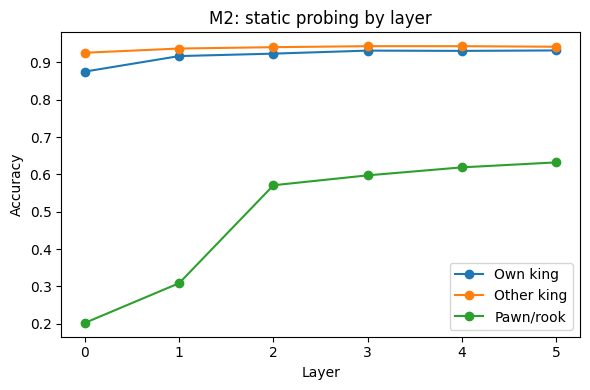

In [7]:
import json
import matplotlib.pyplot as plt

with open("/content/drive/MyDrive/kpk_project/probe_results.json") as f:
    m2 = json.load(f)

layers = sorted(int(k) for k in m2.keys())
fig, ax = plt.subplots(figsize=(6, 4))
for task, label in [("own_king", "Own king"), ("other_king", "Other king"), ("special_sq", "Pawn/rook")]:
    accs = [m2[str(l)][task]["acc"] for l in layers]
    ax.plot(layers, accs, marker='o', label=label)
ax.set_xlabel("Layer"); ax.set_ylabel("Accuracy"); ax.set_title("M2: static probing by layer")
ax.legend(); ax.set_xticks(layers)
plt.tight_layout(); plt.show()

***M3 (leggibilità WDL/DTZ, vanilla vs multitask)***
Vanilla WDL/DTZ legibility rises then degrades by layer: outcome information
is built up to support move choice but not specifically preserved afterward.
Multitask rises monotonically to a much higher ceiling at layer 5 (0.93 vs 0.71),
exactly the layer its auxiliary head was attached to.

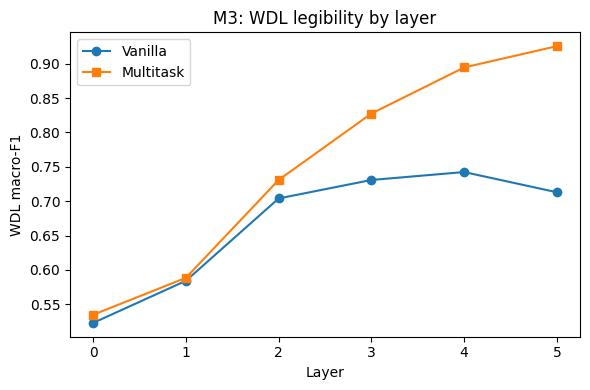

In [ ]:
with open("/content/drive/MyDrive/kpk_project/probe_results.json") as f:
    m3_vanilla = json.load(f)
with open("/content/drive/MyDrive/kpk_project/probe_results_multitask.json") as f:
    m3_multitask = json.load(f)

layers = sorted(int(k) for k in m3_vanilla.keys())
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(layers, [m3_vanilla[str(l)]["wdl"]["macro_acc"] for l in layers], marker='o', label="Vanilla")
ax.plot(layers, [m3_multitask[str(l)]["wdl"]["macro_acc"] for l in layers], marker='s', label="Multitask")
ax.set_xlabel("Layer"); ax.set_ylabel("WDL macro-F1"); ax.set_title("M3: WDL legibility by layer")
ax.legend(); ax.set_xticks(layers)
plt.tight_layout(); plt.show()

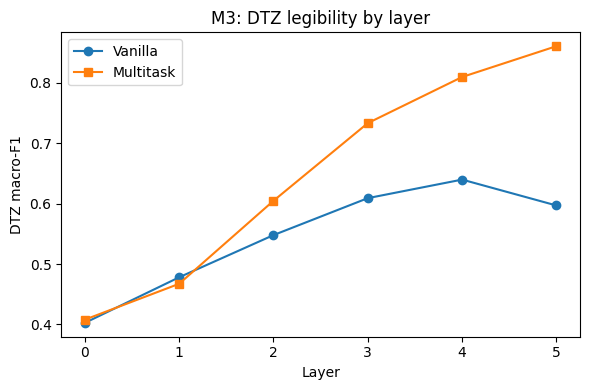

In [10]:
with open("/content/drive/MyDrive/kpk_project/probe_results.json") as f:
    m3_vanilla = json.load(f)
with open("/content/drive/MyDrive/kpk_project/probe_results_multitask.json") as f:
    m3_multitask = json.load(f)


layers = sorted(int(k) for k in m3_vanilla.keys())
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(layers, [m3_vanilla[str(l)]["dtz_bucket"]["macro_acc"] for l in layers], marker='o', label="Vanilla")
ax.plot(layers, [m3_multitask[str(l)]["dtz_bucket"]["macro_acc"] for l in layers], marker='s', label="Multitask")
ax.set_xlabel("Layer"); ax.set_ylabel("DTZ macro-F1"); ax.set_title("M3: DTZ legibility by layer")
ax.legend(); ax.set_xticks(layers)
plt.tight_layout(); plt.show()

***M4 (generalizzazione, vanilla vs multitask)***
Every model-based probe clearly beats the constant baseline out of range; the
geometric baseline barely does. The model's advantage over raw geometry is real
here, unlike in M3's static WDL task, where the baseline actually wins.

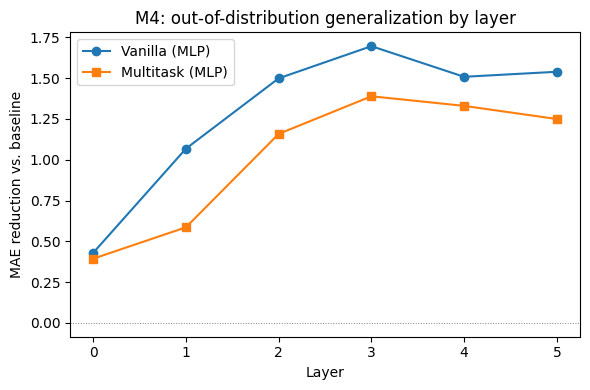

In [ ]:
with open("/content/drive/MyDrive/kpk_project/m4_results.json") as f:
    m4_vanilla = json.load(f)
with open("/content/drive/MyDrive/kpk_project/m4_results_multitask.json") as f:
    m4_multitask = json.load(f)

layers = sorted(int(k) for k in m4_vanilla.keys())
def beats_baseline(d, l, probe="mlp"):
    m = d[str(l)][probe]
    return m["baseline_mae"] - m["test_mae"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(layers, [beats_baseline(m4_vanilla, l) for l in layers], marker='o', label="Vanilla (MLP)")
ax.plot(layers, [beats_baseline(m4_multitask, l) for l in layers], marker='s', label="Multitask (MLP)")
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_xlabel("Layer"); ax.set_ylabel("MAE reduction vs. baseline")
ax.set_title("M4: out-of-distribution generalization by layer")
ax.legend(); ax.set_xticks(layers)
plt.tight_layout(); plt.show()

***M5 (patching causale, vanilla vs multitask, con stratificazione)***
Vanilla: weak, diffuse recovery across layers 2-5 (median 0.05-0.21), no layer
dominant. Multitask: near-perfect, concentrated recovery at layer 5
(median ~1.00). Stratified by zugzwang vs generic: contrary to the initial
hypothesis, generic positions match or exceed zugzwang positions at every layer
in both models. The representation is weakest exactly where it matters tactically
most, consistent with M3/M4's finding that those are already the hardest positions
to represent.

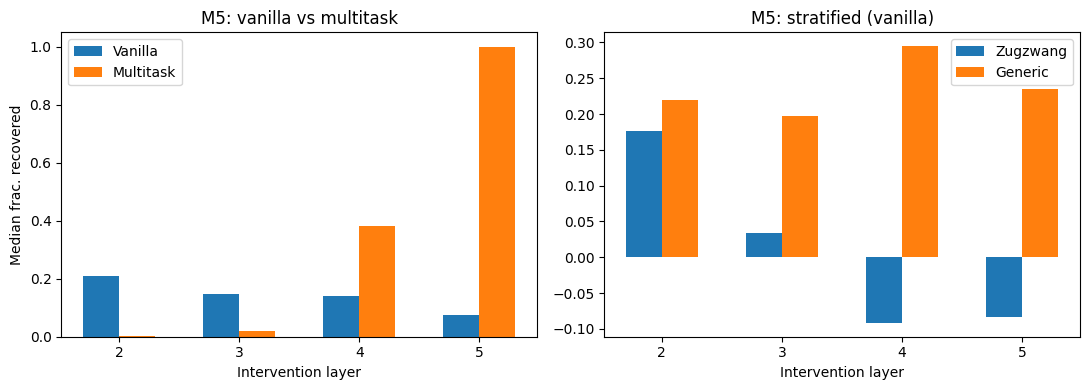

In [ ]:
with open("/content/drive/MyDrive/kpk_project/m5_results_vanilla_stratified.json") as f:
    m5_vanilla = json.load(f)
with open("/content/drive/MyDrive/kpk_project/m5_results_multitask_stratified.json") as f:
    m5_multitask = json.load(f)

layers = sorted(int(k) for k in m5_vanilla["summary"].keys() if int(k) != 0)  # layer 0 = caso degenere

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# pannello 1: vanilla vs multitask
axes[0].bar([l - 0.15 for l in layers], [m5_vanilla["summary"][str(l)]["median"] for l in layers],
            width=0.3, label="Vanilla")
axes[0].bar([l + 0.15 for l in layers], [m5_multitask["summary"][str(l)]["median"] for l in layers],
            width=0.3, label="Multitask")
axes[0].set_xlabel("Intervention layer"); axes[0].set_ylabel("Median frac. recovered")
axes[0].set_title("M5: vanilla vs multitask"); axes[0].legend(); axes[0].set_xticks(layers)

# pannello 2: zugzwang vs generico (stratificato), solo vanilla
zz = [m5_vanilla["summary_by_group"][str(l)]["zugzwang"].get("median", float("nan")) for l in layers]
gen = [m5_vanilla["summary_by_group"][str(l)]["generic"].get("median", float("nan")) for l in layers]
axes[1].bar([l - 0.15 for l in layers], zz, width=0.3, label="Zugzwang")
axes[1].bar([l + 0.15 for l in layers], gen, width=0.3, label="Generic")
axes[1].set_xlabel("Intervention layer"); axes[1].set_title("M5: stratified (vanilla)")
axes[1].legend(); axes[1].set_xticks(layers)

plt.tight_layout(); plt.show()

**M6**: smooth and monotonic tradeoff between KPK and KRK accuracy as α moves from 0 to 1; no collapse, but the signature of a merge-compatible pair of task vectors. Asymmetric:
at α=0.75, KRK recovers nearly all its own ceiling while KPK gives up ~9%. Even
α=0 (zero KRK training) reaches 47% KRK accuracy via shared-vocabulary transfer.

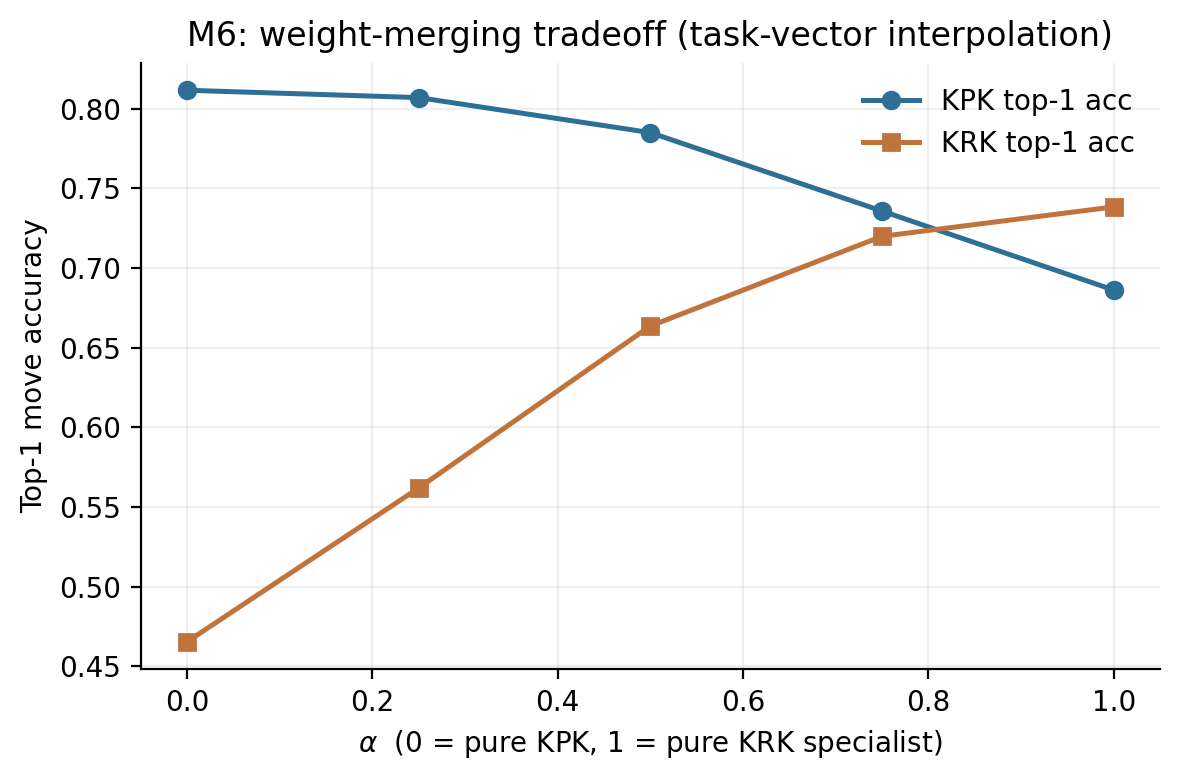

In [ ]:
import json
import matplotlib.pyplot as plt

# leggi il risultato principale, e se esiste anche quello con la griglia fine
with open("/content/drive/MyDrive/kpk_project/merge_results.json") as f:
    coarse = json.load(f)["results"]

fine = []
try:
    with open("/content/drive/MyDrive/kpk_project/merge_results_fine.json") as f:
        fine = json.load(f)["results"]
except FileNotFoundError:
    pass

all_points = sorted(coarse + fine, key=lambda r: r["alpha"])
alphas = [r["alpha"] for r in all_points]
kpk_acc = [r["kpk_top1_acc"] for r in all_points]
krk_acc = [r["krk_top1_acc"] for r in all_points]

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
ax.plot(alphas, kpk_acc, marker='o', color='#2e6f95', label='KPK top-1 acc', linewidth=1.8)
ax.plot(alphas, krk_acc, marker='s', color='#c0733d', label='KRK top-1 acc', linewidth=1.8)
ax.set_xlabel(r"$\alpha$  (0 = pure KPK, 1 = pure KRK specialist)")
ax.set_ylabel("Top-1 move accuracy")
ax.set_title("M6: weight-merging tradeoff (task-vector interpolation)")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/kpk_project/m6_figure.png", dpi=200, bbox_inches='tight')
plt.show()